# 24BAD099 - Rithish A
# EXPT NO: 6
## Implementation of Ensemble Techniques and Handling Class Imbalance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

### SCENARIO 1 - Bagging

Decision Tree Accuracy: 1.0000
Bagging Accuracy: 1.0000


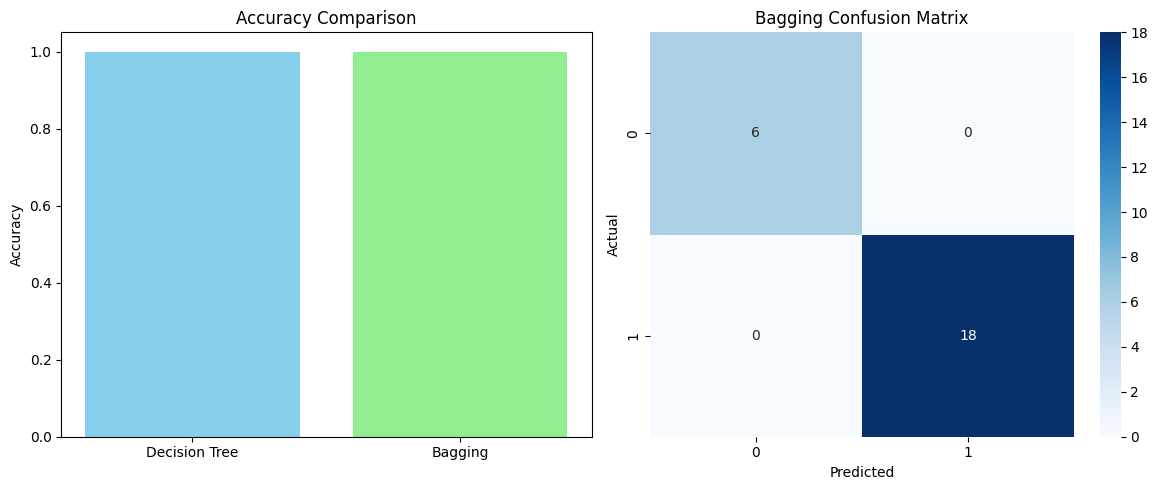

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
df_diabetes = pd.read_csv(r'd:\class materials AI&DS\sem 4\ML\Lab\EXP-6\diabetes_bagging.csv')
X_diab = df_diabetes.drop('Outcome', axis=1)
y_diab = df_diabetes['Outcome']
X_train_diab, X_test_diab, y_train_diab, y_test_diab = train_test_split(X_diab, y_diab, test_size=0.2, random_state=42)

# Scale features
scaler_diab = StandardScaler()
X_train_diab_scaled = scaler_diab.fit_transform(X_train_diab)
X_test_diab_scaled = scaler_diab.transform(X_test_diab)

# 2. Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_diab_scaled, y_train_diab)
dt_pred = dt.predict(X_test_diab_scaled)
dt_acc = accuracy_score(y_test_diab, dt_pred)

# 3. Apply BaggingClassifier
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bagging.fit(X_train_diab_scaled, y_train_diab)
bagging_pred = bagging.predict(X_test_diab_scaled)
bagging_acc = accuracy_score(y_test_diab, bagging_pred)

print(f"Decision Tree Accuracy: {dt_acc:.4f}")
print(f"Bagging Accuracy: {bagging_acc:.4f}")

# 4. Visualization
plt.figure(figsize=(12, 5))

# Accuracy comparison bar graph
plt.subplot(1, 2, 1)
plt.bar(['Decision Tree', 'Bagging'], [dt_acc, bagging_acc], color=['skyblue', 'lightgreen'])
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')

# Confusion matrix for Bagging
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test_diab, bagging_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Bagging Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

### SCENARIO 2 - Boosting (AdaBoost, Gradient Boosting)


AdaBoost Accuracy: 1.0000
Gradient Boosting Accuracy: 1.0000


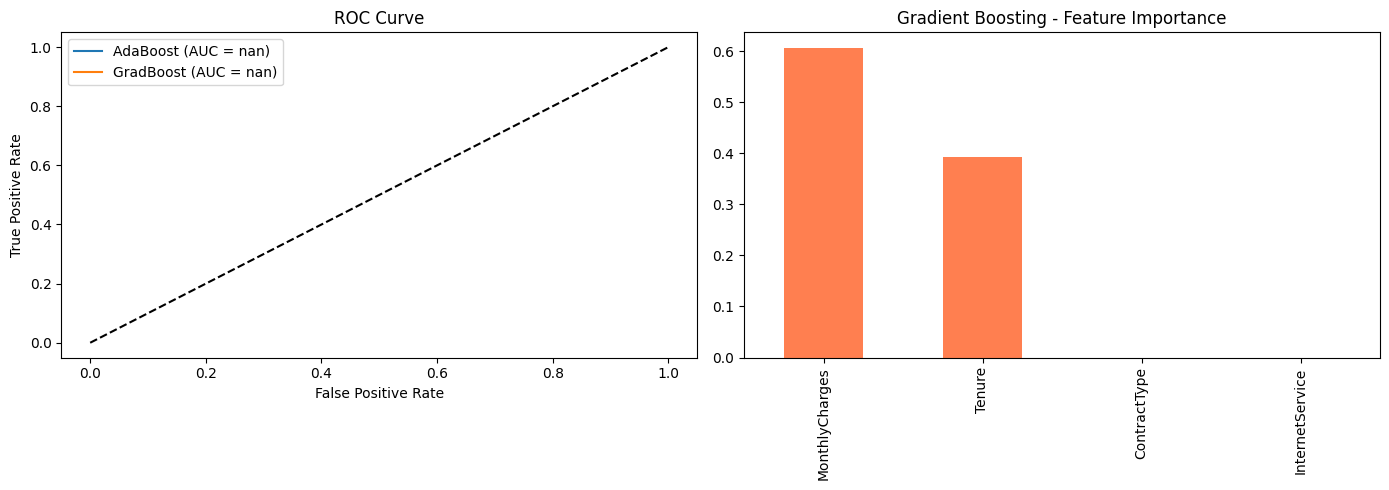

In [4]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Load dataset
df_churn = pd.read_csv(r'd:\class materials AI&DS\sem 4\ML\Lab\EXP-6\churn_boosting.csv')

# Data preparation
for col in df_churn.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_churn[col] = le.fit_transform(df_churn[col])

# Scale features
scaler_churn = StandardScaler()

target_col = 'Churn' if 'Churn' in df_churn.columns else df_churn.columns[-1]
X_churn = df_churn.drop(target_col, axis=1)
y_churn = df_churn[target_col]
X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42)

X_train_ch_scaled = scaler_churn.fit_transform(X_train_ch)
X_test_ch_scaled = scaler_churn.transform(X_test_ch)

# 2. Train AdaBoost & Gradient Boosting
ada = AdaBoostClassifier(random_state=42, n_estimators=50)
ada.fit(X_train_ch_scaled, y_train_ch)
ada_pred = ada.predict(X_test_ch_scaled)
ada_probs = ada.predict_proba(X_test_ch_scaled)[:, 1]

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_ch_scaled, y_train_ch)
gb_pred = gb.predict(X_test_ch_scaled)
gb_probs = gb.predict_proba(X_test_ch_scaled)[:, 1]

print(f"AdaBoost Accuracy: {accuracy_score(y_test_ch, ada_pred):.4f}")
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test_ch, gb_pred):.4f}")

# 3. Visualization: ROC Curve & Feature Importance plot
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
fpr_ada, tpr_ada, _ = roc_curve(y_test_ch, ada_probs)
fpr_gb, tpr_gb, _ = roc_curve(y_test_ch, gb_probs)
plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {auc(fpr_ada, tpr_ada):.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'GradBoost (AUC = {auc(fpr_gb, tpr_gb):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.subplot(1, 2, 2)
feat_imp = pd.Series(gb.feature_importances_, index=X_churn.columns).sort_values(ascending=False).head(10)
feat_imp.plot(kind='bar', color='coral')
plt.title('Gradient Boosting - Feature Importance')

plt.tight_layout()
plt.show()

### SCENARIO 3 - Random Forest


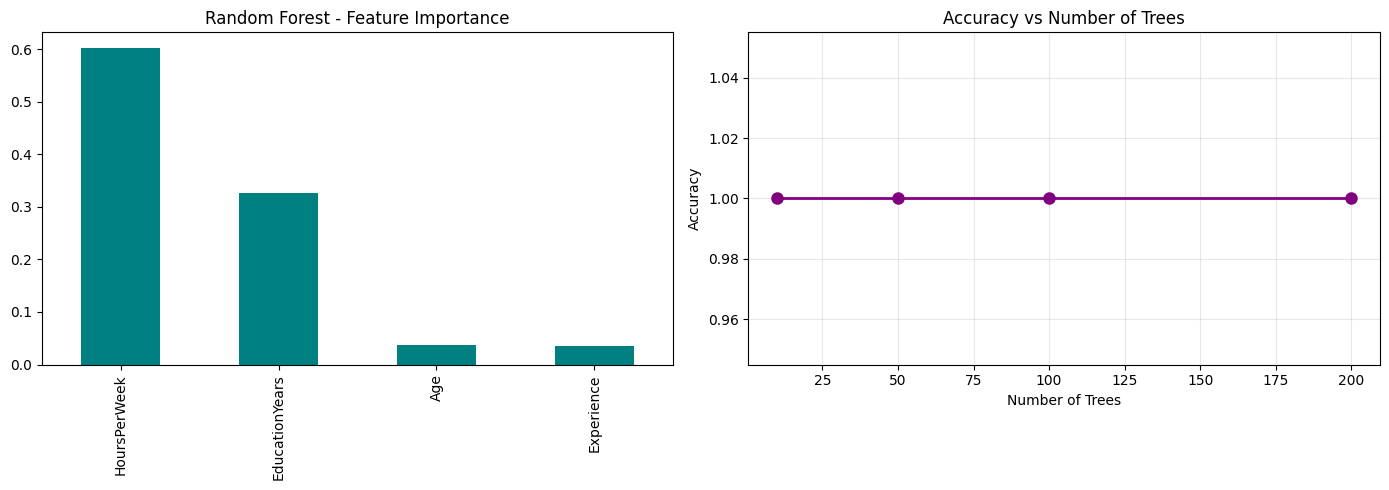

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Load dataset
df_income = pd.read_csv(r'd:\class materials AI&DS\sem 4\ML\Lab\EXP-6\income_random_forest.csv')
# Encoding categorical columns
for col in df_income.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_income[col] = le.fit_transform(df_income[col])

# Scale features
scaler_income = StandardScaler()

target_col = 'Income' if 'Income' in df_income.columns else df_income.columns[-1]
X_inc = df_income.drop(target_col, axis=1)
y_inc = df_income[target_col]
X_train_inc, X_test_inc, y_train_inc, y_test_inc = train_test_split(X_inc, y_inc, test_size=0.2, random_state=42)

X_train_inc_scaled = scaler_income.fit_transform(X_train_inc)
X_test_inc_scaled = scaler_income.transform(X_test_inc)

# 2. Train Random Forest & Tune number of trees
n_estimators_list = [10, 50, 100, 200]
accuracies = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train_inc_scaled, y_train_inc)
    preds = rf.predict(X_test_inc_scaled)
    accuracies.append(accuracy_score(y_test_inc, preds))
    
# Final evaluation on best model
best_idx = np.argmax(accuracies)
best_n_trees = n_estimators_list[best_idx]
best_rf = RandomForestClassifier(n_estimators=best_n_trees, random_state=42, n_jobs=-1).fit(X_train_inc_scaled, y_train_inc)

# 3. Visualization
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
feat_imp_rf = pd.Series(best_rf.feature_importances_, index=X_inc.columns).sort_values(ascending=False).head(10)
feat_imp_rf.plot(kind='bar', color='teal')
plt.title('Random Forest - Feature Importance')

plt.subplot(1, 2, 2)
plt.plot(n_estimators_list, accuracies, marker='o', linestyle='-', color='purple', linewidth=2, markersize=8)
plt.title('Accuracy vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### SCENARIO 4 - Stacking


lr Accuracy: 0.8333
svm Accuracy: 0.8750
dt Accuracy: 0.9583
Stacking Accuracy: 0.9583


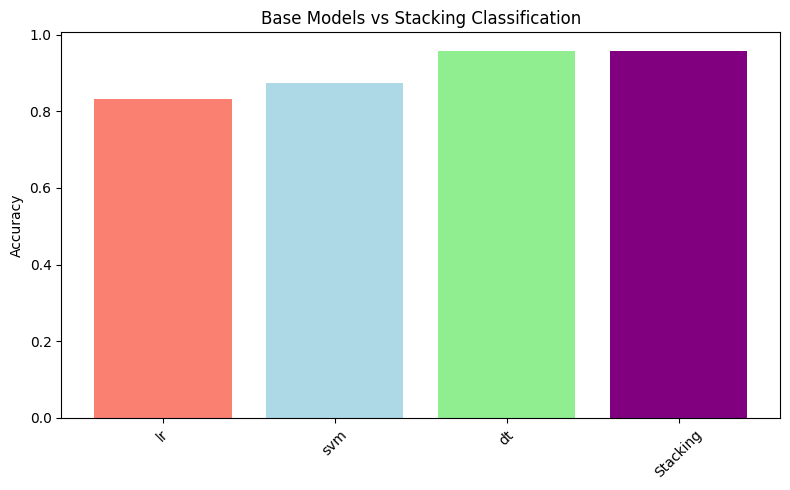

In [6]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
df_heart = pd.read_csv(r'd:\class materials AI&DS\sem 4\ML\Lab\EXP-6\heart_stacking.csv')

# Scale features
scaler_heart = StandardScaler()

target_col = 'target' if 'target' in df_heart.columns else df_heart.columns[-1]
X_ht = df_heart.drop(target_col, axis=1)
y_ht = df_heart[target_col]
X_train_ht, X_test_ht, y_train_ht, y_test_ht = train_test_split(X_ht, y_ht, test_size=0.2, random_state=42)

X_train_ht_scaled = scaler_heart.fit_transform(X_train_ht)
X_test_ht_scaled = scaler_heart.transform(X_test_ht)

# 2. Train base models 
estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

model_accs = {}
for name, model in estimators:
    model.fit(X_train_ht_scaled, y_train_ht)
    model_accs[name] = accuracy_score(y_test_ht, model.predict(X_test_ht_scaled))

# 3. Combine using StackingClassifier
stack_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5)
stack_model.fit(X_train_ht_scaled, y_train_ht)
stack_acc = accuracy_score(y_test_ht, stack_model.predict(X_test_ht_scaled))
model_accs['Stacking'] = stack_acc

for name, acc in model_accs.items():
    print(f"{name} Accuracy: {acc:.4f}")

# 4. Visualization: Model comparison bar chart
plt.figure(figsize=(8, 5))
plt.bar(model_accs.keys(), model_accs.values(), color=['salmon', 'lightblue', 'lightgreen', 'purple'])
plt.title('Base Models vs Stacking Classification')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### SCENARIO 5 - SMOTE


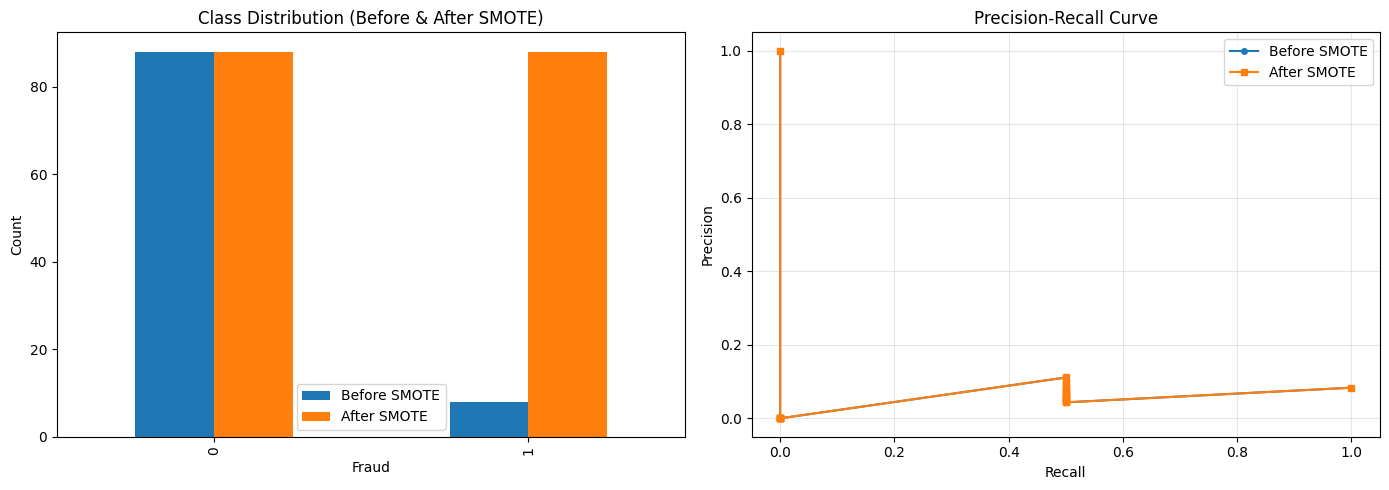


--- BEFORE SMOTE ---
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24


--- AFTER SMOTE ---
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        22
           1       0.00      0.00      0.00         2

    accuracy                           0.75        24
   macro avg       0.45      0.41      0.43        24
weighted avg       0.83      0.75      0.79        24



In [7]:
# Install imblearn if not already installed -> !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
df_fraud = pd.read_csv(r'd:\class materials AI&DS\sem 4\ML\Lab\EXP-6\fraud_smote.csv')

# Scale features
scaler_fraud = StandardScaler()

target_col = 'Fraud' if 'Fraud' in df_fraud.columns else 'Class' if 'Class' in df_fraud.columns else df_fraud.columns[-1]
X_fr = df_fraud.drop(target_col, axis=1)
y_fr = df_fraud[target_col]

X_train_fr, X_test_fr, y_train_fr, y_test_fr = train_test_split(X_fr, y_fr, test_size=0.2, random_state=42, stratify=y_fr)

X_train_fr_scaled = scaler_fraud.fit_transform(X_train_fr)
X_test_fr_scaled = scaler_fraud.transform(X_test_fr)

# 2. Train model BEFORE SMOTE
lr_before = LogisticRegression(max_iter=1000, random_state=42)
lr_before.fit(X_train_fr_scaled, y_train_fr)
pred_before = lr_before.predict(X_test_fr_scaled)
probs_before = lr_before.predict_proba(X_test_fr_scaled)[:, 1]

# 3. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_fr_scaled, y_train_fr)

# Train model AFTER SMOTE
lr_after = LogisticRegression(max_iter=1000, random_state=42)
lr_after.fit(X_train_sm, y_train_sm)
pred_after = lr_after.predict(X_test_fr_scaled)
probs_after = lr_after.predict_proba(X_test_fr_scaled)[:, 1]

# 4. Visualization
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
dist_before = y_train_fr.value_counts()
dist_after = pd.Series(y_train_sm).value_counts()
pd.DataFrame({'Before SMOTE': dist_before, 'After SMOTE': dist_after}).plot(kind='bar', ax=plt.gca())
plt.title('Class Distribution (Before & After SMOTE)')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
prec_bef, rec_bef, _ = precision_recall_curve(y_test_fr, probs_before)
prec_aft, rec_aft, _ = precision_recall_curve(y_test_fr, probs_after)
plt.plot(rec_bef, prec_bef, label='Before SMOTE', marker='o', markersize=4)
plt.plot(rec_aft, prec_aft, label='After SMOTE', marker='s', markersize=4)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("\n--- BEFORE SMOTE ---")
print(classification_report(y_test_fr, pred_before))
print("\n--- AFTER SMOTE ---")
print(classification_report(y_test_fr, pred_after))